# 4. Where audio does win, and what breadth does to the gap

Notebook 02 showed that a model reading the paperwork beats every audio model at naming the species.
Two responses to that are worth testing.

The first is that species is the wrong question. Ask one the paperwork cannot answer: given that this
is a sperm whale, does the clip contain a click?

The second is that 134 recordings is too small a design. The archive holds 54 species over 393
tapes, so the same question can be asked over eleven species and 228 recordings without downloading
anything.

Both are run below. One of them produces the only comparison in this project where hearing the
recording wins by an amount the design can separate.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Works whether the kernel starts in the repository root or in experiments/.
sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent))

from src.config import load_config
from src.evaluate import families, tables
from src.results import config_directory

narrow = load_config("configs/base.yaml")
wide = load_config("configs/wide.yaml")
pd.set_option("display.width", 180)

print(f"{narrow.name}: {len(narrow.dataset.species)} species")
print(f"{wide.name}: {len(wide.dataset.species)} species")

base_10k: 3 species
wide_10k: 11 species


## 1. Posing a question the paperwork cannot answer

Each call type is posed inside a single species, so the collection code cannot give the answer away:
every clip in the task carries the same species. The control still sees the site, the coordinates,
the noise conditions and the collection code, because collections differ in what they recorded even
within one species.

A task has to clear 60 clips over 10 independent tapes to be fitted at all. Eight do.

In [2]:
call_types = [f for f in families.discover(narrow) if f.key != families.SPECIES_FAMILY]
print(f"{len(call_types)} call type tasks, each with its own control")

pd.DataFrame(
    [
        {
            "task": f.title,
            "models": ", ".join(f.members),
            "control": f.control,
            "classes": ", ".join(f.class_names),
        }
        for f in call_types
    ]
)

8 call type tasks, each with its own control


,task,models,control,classes
0,"KillerWhale, call",calltype_killerwhale_call,calltype_killerwhale_call_context,"absent, present"
1,"KillerWhale, chirp",calltype_killerwhale_chirp,calltype_killerwhale_chirp_context,"absent, present"
2,"KillerWhale, click",calltype_killerwhale_click,calltype_killerwhale_click_context,"absent, present"
3,"KillerWhale, squeal",calltype_killerwhale_squeal,calltype_killerwhale_squeal_context,"absent, present"
4,"KillerWhale, whistle",calltype_killerwhale_whistle,calltype_killerwhale_whistle_context,"absent, present"
5,"SpermWhale, click",calltype_spermwhale_click,calltype_spermwhale_click_context,"absent, present"
6,"SpermWhale, coda","calltype_spermwhale_coda, calltype_spermwhale_...",calltype_spermwhale_coda_context,"absent, present"
7,"SpermWhale, whistle",calltype_spermwhale_whistle,calltype_spermwhale_whistle_context,"absent, present"


## 2. What they score

Every margin is the audio model against its own context control on identical folds. The trees ran ten
repeats, so fifty splits; one network ran a single split, so five.

In [3]:
rows = []
for family in call_types:
    for _, row in tables.family_margins(narrow, family).iterrows():
        rows.append({"task": family.title, **row})

margins = pd.DataFrame(rows).sort_values("margin", ascending=False)
margins["resolves"] = margins.p_value < 0.05
positive = (margins.margin > 0).sum()
print(f"{positive} of {len(margins)} margins are positive, {margins.resolves.sum()} resolves")
margins[
    ["task", "mean", "control", "margin", "low", "high", "p_value", "agreeing", "folds", "resolves"]
].round(4)

8 of 9 margins are positive, 1 resolves


,task,mean,control,margin,low,high,p_value,agreeing,folds,resolves
8,"SpermWhale, whistle",0.7117,0.5265,0.1852,-0.1035,0.4740,0.2034,29,50,False
2,"KillerWhale, click",0.6007,0.4564,0.1444,-0.0175,0.3062,0.0793,40,50,False
6,"SpermWhale, coda",0.5655,0.4338,0.1318,-0.2158,0.4793,0.3519,4,5,False
5,"SpermWhale, click",0.7053,0.5801,0.1252,-0.0172,0.2677,0.0835,43,50,False
3,"KillerWhale, squeal",0.7685,0.6524,0.1161,-0.0799,0.3121,0.2398,36,50,False
4,"KillerWhale, whistle",0.5642,0.4632,0.1011,0.0149,0.1872,0.0225,41,50,True
7,"SpermWhale, coda",0.5702,0.5445,0.0257,-0.1823,0.2338,0.8047,23,50,False
1,"KillerWhale, chirp",0.5575,0.5475,0.0100,-0.0855,0.1055,0.8346,21,50,False
0,"KillerWhale, call",0.6892,0.7121,-0.0229,-0.3377,0.2919,0.8842,29,50,False


Killer whale whistle is the only comparison in this repository where listening to the recording beats
not listening to it by an amount the design separates. Eight of nine margins point the right way,
which is worth something on its own, but a direction is not a result.

Sperm whale whistle has the largest margin here and does not resolve. It rests on eleven recordings,
and a task carried by eleven tapes has an effective sample size of eleven however many clips it spans.

In [4]:
resolved = margins[margins.resolves]
for _, row in resolved.iterrows():
    print(
        f"{row.task}: {row.margin:+.3f}, p = {row.p_value:.3f}, "
        f"{int(row.agreeing)} of {int(row.folds)} agreeing"
    )

widest = margins.iloc[0]
print()
print(f"largest margin: {widest.task} at {widest.margin:+.3f}, p = {widest.p_value:.2f}")
print(f"its interval spans {widest.low:+.3f} to {widest.high:+.3f}, which includes zero")

KillerWhale, whistle: +0.101, p = 0.022, 41 of 50 agreeing

largest margin: SpermWhale, whistle at +0.185, p = 0.20
its interval spans -0.104 to +0.474, which includes zero


## 3. A finding that did not survive a better control

Sperm whale click used to resolve. It sat at +0.141 with p = 0.044 while the context control could
not see the collection code. Giving the control that one field moved it to +0.125 at p = 0.084.

Nothing about the audio model changed. A result that survives only while the control is missing a
column is not a result, and this section exists so the retraction is as visible as the claim was.

In [5]:
click = margins[margins.task.str.contains("click") & margins.task.str.contains("Sperm")]
click[["task", "mean", "control", "margin", "p_value", "agreeing", "folds"]].round(4)

,task,mean,control,margin,p_value,agreeing,folds
5,"SpermWhale, click",0.7053,0.5801,0.1252,0.0835,43,50


## 4. The same question over eleven species

`configs/wide.yaml` differs from `configs/base.yaml` in the species list and nothing else. Same band,
same window, same seed, same fold rule. Eleven species carrying at least ten surviving tapes each.

The prediction written down before this ran was that every score would fall, because eleven classes
is harder than three, and that the interesting number is whether the gap narrows.

In [6]:
coverage = pd.read_csv(wide.paths.metadata / f"audit_coverage_{wide.name}.csv")
manifest = pd.read_parquet(wide.paths.metadata / f"manifest_{wide.name}.parquet")
recordings = manifest[manifest.keep].tape_id.nunique()

print(f"{coverage.kept_clips.sum()} clips over {recordings} recordings")
print(f"summing per species gives {coverage.kept_tapes.sum()}, because some tapes carry two")
coverage

7723 clips over 228 recordings
summing per species gives 238, because some tapes carry two


,species,clips,tapes,kept_clips,kept_tapes,kept_hours
0,Beluga_WhiteWhale,150,12,131,12,0.083201
1,HumpbackWhale,604,14,546,12,1.954924
2,KillerWhale,2647,65,2601,65,1.649322
3,Long_FinnedPilotWhale,1104,18,1067,18,0.854631
4,NorthernRightWhale,486,22,342,17,0.206564
5,Short_Finned(Pacific)PilotWhale,607,12,558,12,0.381441
6,SpermWhale,1379,63,1013,58,12.230502
7,SpinnerDolphin,524,12,443,12,0.652978
8,StripedDolphin,681,10,658,10,0.358903
9,Walrus,273,11,262,11,0.287265


## 5. The gap widened

Every score fell, as expected. The gap did not narrow, it roughly doubled.

Doubling the recordings did not rescue the audio. It made the paperwork look better, because there is
more paperwork to go on when there are more animals to tell apart.

In [7]:
comparison = []
for cfg in (narrow, wide):
    family = next(f for f in families.discover(cfg) if f.key == families.SPECIES_FAMILY)
    scores = tables.headline(tables.comparison(cfg, list(family.names))).set_index("model")["mean"]
    comparison.append(scores.rename(f"{len(cfg.dataset.species)} species"))

side_by_side = pd.concat(comparison, axis=1).loc[["logbook", "metadata", "xgboost"]]
side_by_side.round(3)

,3 species,11 species
model,,
logbook,0.997,0.920
metadata,0.868,0.577
xgboost,0.757,0.424


In [8]:
for cfg in (narrow, wide):
    family = next(f for f in families.discover(cfg) if f.key == families.SPECIES_FAMILY)
    floor = families.strongest_floor(cfg, family)
    row = tables.family_margins(cfg, family, control=floor).set_index("model").loc["xgboost"]
    print(
        f"{len(cfg.dataset.species):2d} species: XGBoost is {row.margin:+.3f} against {floor}, "
        f"p = {row.p_value:.1e}, {int(row.agreeing)} of {int(row.folds)}"
    )

 3 species: XGBoost is -0.241 against logbook, p = 9.5e-09, 50 of 50
11 species: XGBoost is -0.496 against logbook, p = 7.7e-17, 50 of 50


## 6. Which field the paperwork leans on changes with breadth

On three species the collection code alone reaches 0.995 and the model splits mostly on sample rate
and latitude. On eleven, most of the gain moves to the noise conditions the recordist wrote down.

The confound is not one field. It is that a written description of the circumstances of a recording
identifies the animal, and which part of the description does the work depends on which animals are
being told apart.

In [9]:
for cfg in (narrow, wide):
    importance = pd.read_csv(config_directory(cfg) / "logbook" / "feature_importance.csv")
    share = importance.groupby("feature").gain.mean()
    share = (share / share.sum()).sort_values(ascending=False).head(4)
    print(f"{len(cfg.dataset.species)} species, what the logbook split on:")
    print(share.round(3).to_string())
    print()

3 species, what the logbook split on:
feature
native_sample_rate    0.458
latitude              0.350
collection_code       0.113
bytes_on_disk         0.049

11 species, what the logbook split on:
feature
cond_water_noise      0.413
cond_reverberation    0.164
longitude             0.086
cond_engine_noise     0.084



## 7. Where the paperwork stops working

The clearest evidence that the logbook is reading one field rather than understanding anything is
what happens on the clips where that field is uninformative.

Test clips are split by whether a giveaway is unique to one species or shared across several. On the
shared side the recording no longer names the animal, and that is where an audio model has to earn
its result.

In [10]:
ambiguity = pd.read_csv(config_directory(narrow) / "ambiguity_breakdown.csv")
wide_view = ambiguity.pivot_table(index="model", columns="subset", values="macro_f1_mean")
wide_view.round(3)

subset,collection code shared by species,collection code unique to a species,native sample rate shared by species,native sample rate unique to a species
model,,,,
cnn,0.404,0.688,0.663,0.624
cnn_small,0.362,0.744,0.678,0.690
logbook,0.426,0.998,0.864,0.932
metadata,0.465,0.868,0.689,0.878
xgboost,0.411,0.754,0.663,0.711


In [11]:
code_split = (
    ambiguity[ambiguity.giveaway == "collection code"].set_index(["model", "subset"]).macro_f1_mean
)
for model in ("logbook", "xgboost"):
    unique = code_split[(model, "collection code unique to a species")]
    shared = code_split[(model, "collection code shared by species")]
    print(
        f"{model:9s} {unique:.3f} where the code names the species, {shared:.3f} where it does not"
    )

shared_clips = ambiguity[ambiguity.subset == "collection code shared by species"].clips.iloc[0]
print()
print(f"on those {shared_clips} clips the logbook is level with the audio models")

logbook   0.998 where the code names the species, 0.426 where it does not
xgboost   0.754 where the code names the species, 0.411 where it does not

on those 359 clips the logbook is level with the audio models


native sample rate


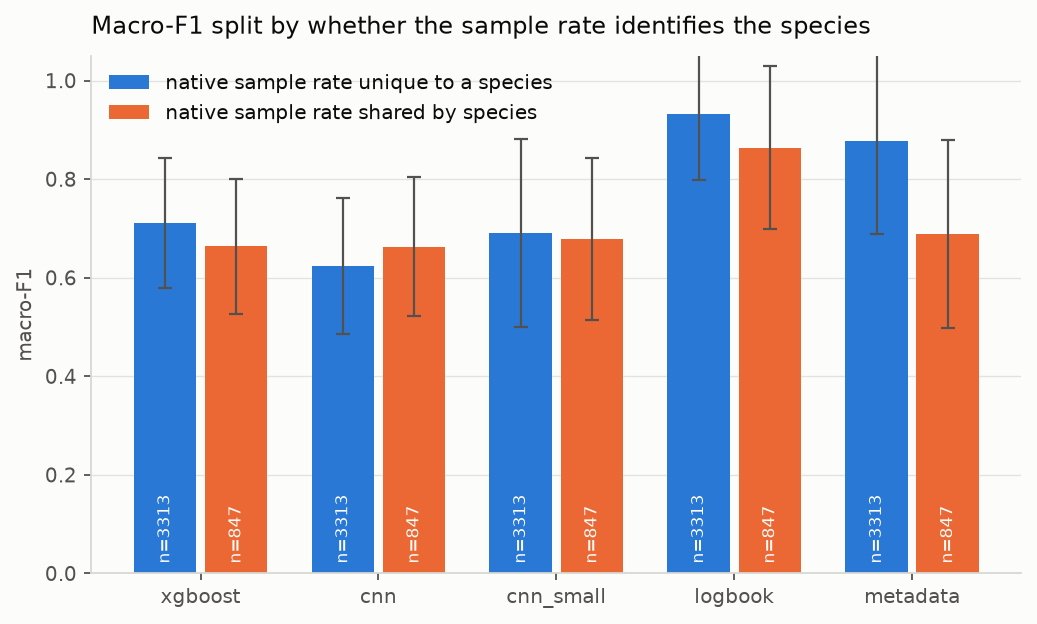

collection code


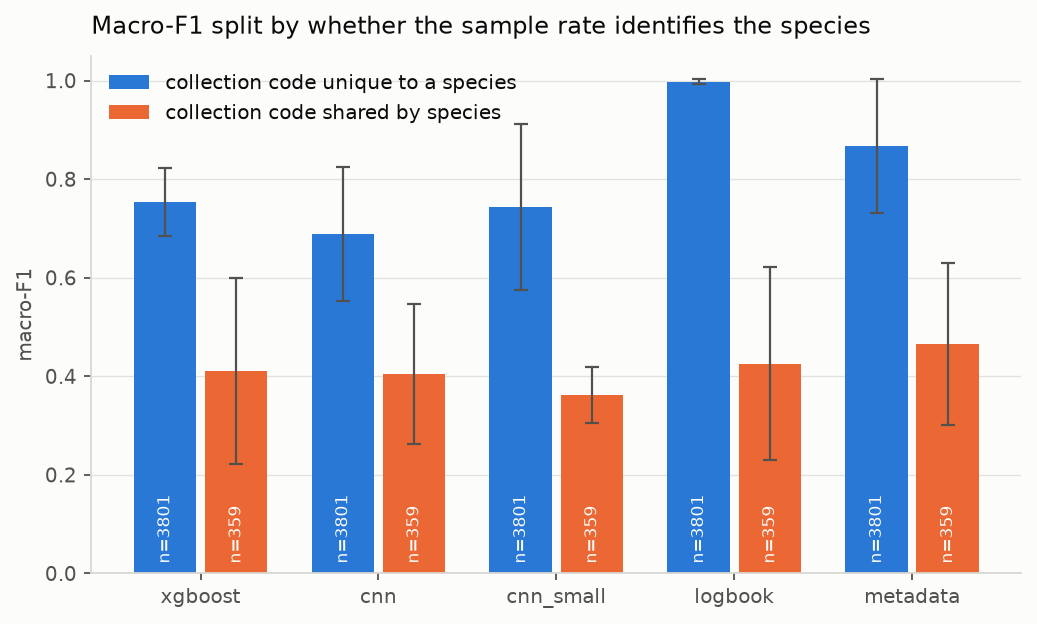

In [12]:
for field in ambiguity.giveaway.unique():
    stem = field.replace(" ", "_")
    path = config_directory(narrow) / f"ambiguity_{stem}.png"
    if path.exists():
        print(field)
        display(Image(filename=str(path)))

## What this notebook does not settle

The call type tasks rest on between ten and forty four recordings each. Eight positive margins out of
nine is suggestive and one resolved comparison is thin evidence, and neither becomes stronger by
being restated.

Eleven species bought more recordings and more classes at the same time, and the two pull against
each other. Some classes land a single test tape in some folds, so those per fold scores rest on one
recording. Eight of the 228 recordings carry two of the eleven species, so the classes sharing a tape
are not scored on independent evidence: long finned pilot whale shares six of its eighteen tapes with
sperm whale.

The networks were not run on the wide set, so nothing here says whether a learned representation
behaves differently at eleven classes.